In [ ]:
# Import pandas for data manipulation
import pandas as pd

In [2]:
data=pd.read_csv('placement.csv')
data

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [4]:
# remove unnamed colm as dataframe has no use of it
data=data.iloc[:,1:]


In [5]:
data

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [6]:
import matplotlib.pyplot as plt


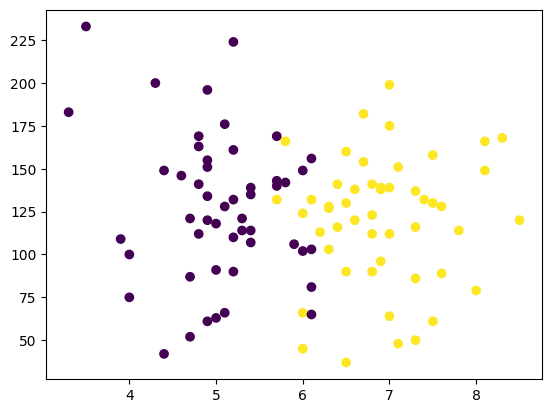

In [7]:
plt.scatter(data['cgpa'],data['iq'],c=data['placement'])

In [10]:
X=data.iloc[:,0:2]
Y=data.iloc[:,-1]

In [11]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [12]:
Y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

In [27]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [28]:
X_train

,cgpa,iq
88,4.4,149.0
19,5.2,132.0
97,6.7,182.0
92,5.2,110.0
3,7.4,132.0
...,...,...
21,7.1,151.0
64,7.0,64.0
53,8.3,168.0
89,4.9,151.0


In [29]:
Y_train

88    0
19    0
97    1
92    0
3     1
     ..
21    1
64    1
53    1
89    0
7     0
Name: placement, Length: 90, dtype: int64

In [30]:
X_test

,cgpa,iq
50,3.5,233.0
34,4.8,163.0
62,6.0,102.0
73,4.9,61.0
42,7.6,89.0
98,6.3,103.0
10,6.0,45.0
87,5.7,132.0
70,6.3,127.0
22,4.9,120.0


In [31]:
Y_test

50    0
34    0
62    0
73    0
42    1
98    1
10    1
87    1
70    1
22    0
Name: placement, dtype: int64

In [33]:
# scale the data to make it more accurate and efficient
from sklearn.preprocessing import StandardScaler

In [35]:
scaler=StandardScaler()

In [36]:
X_train=scaler.fit_transform(X_train)

In [37]:
X_train

array([[-1.43692569,  0.64582689],
       [-0.7336038 ,  0.20212903],
       [ 0.58512474,  1.50712274],
       [-0.7336038 , -0.37206821],
       [ 1.20053139,  0.20212903],
       [ 1.28844663, -1.65096205],
       [ 0.67303998,  0.43702789],
       [-0.03028191, -0.00666997],
       [ 0.05763332,  0.20212903],
       [-0.82151904,  1.35052349],
       [ 0.76095521,  0.38482815],
       [ 0.05763332, -1.12896456],
       [ 0.40929427, -0.89406569],
       [-0.90943428, -0.16326921],
       [-0.99734951,  1.87252098],
       [-0.55777333,  0.28042865],
       [-0.82151904, -1.52046267],
       [-0.64568857, -0.08496959],
       [ 1.11261616, -1.93806066],
       [ 0.84887045, -0.31986846],
       [-0.7336038 ,  0.95902538],
       [-1.26109522,  0.56752727],
       [-1.87650188, -0.39816808],
       [ 2.16759899, -0.11106946],
       [-0.82151904,  0.09772953],
       [-1.17317999, -0.97236532],
       [-0.99734951,  0.25432877],
       [ 0.23346379,  0.09772953],
       [-1.78858664,

In [38]:
X_test=scaler.transform(X_test)

In [39]:
X_test

array([[-2.22816282,  2.83821633],
       [-1.08526475,  1.01122513],
       [-0.03028191, -0.5808672 ],
       [-0.99734951, -1.65096205],
       [ 1.37636186, -0.92016557],
       [ 0.23346379, -0.55476733],
       [-0.03028191, -2.06856003],
       [-0.29402762,  0.20212903],
       [ 0.23346379,  0.07162965],
       [-0.99734951, -0.11106946]])

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
clf=LogisticRegression()

In [42]:
# model training
clf.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [46]:
#model evaluation
y_test=clf.predict(X_test)

In [45]:
y_pred=clf.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 1, 0, 0, 1, 0])

In [47]:
from sklearn.metrics import accuracy_score


In [48]:
accuracy_score(Y_test,y_pred)

0.8

In [52]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

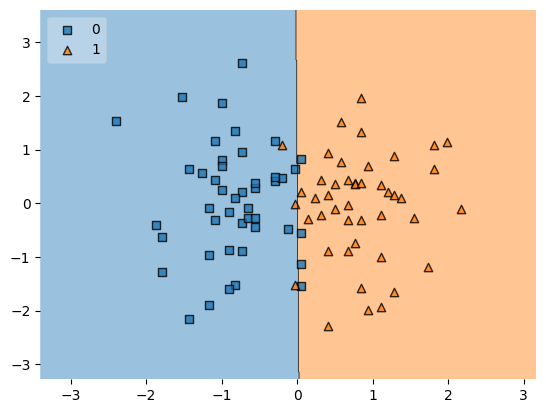

In [53]:
plot_decision_regions(X=X_train, y=Y_train.values, clf=clf, legend=2)

In [54]:
import pickle

In [55]:
pickle.dump(clf,open('model.pkl','wb'))